In [3]:
# Tự nạp lại raw_feature.py mỗi khi sửa, không cần restart kernel
%load_ext autoreload
%autoreload 2
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from raw_feature import compute_feature

In [4]:
# Load split-index, dựng src/dest, lấy TRAN train (quyết định cột chỉ trên train)
dtype = {"From Bank": str, "Account": str, "To Bank": str, "Account.1": str}
df = pd.read_csv("dataset_high/HI-Small_Trans_split_index.csv", dtype=dtype)
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df["src"]  = df["From Bank"] + " | " + df["Account"]
df["dest"] = df["To Bank"]   + " | " + df["Account.1"]

train = df[df["split"] == "train"]
feat = compute_feature(train)
print("feat shape:", feat.shape)

feat shape: (512713, 20)


In [5]:
# Profile mọi cột để TỰ quyết định nhóm (thay cho việc hardcode ratio_cols/special)
profile = pd.DataFrame({
    "min":     feat.min(),
    "max":     feat.max(),
    "pct_neg": (feat < 0).mean() * 100,        # % giá trị âm -> >0 nghĩa là không dùng được log1p
    "in_0_1":  (feat.min() >= 0) & (feat.max() <= 1),  # True = ratio nằm gọn trong [0,1]
    "skew":    feat.skew(),
}).round(3)

print("== Cột nằm trong [0,1] (ứng viên ratio_cols) ==")
print(profile.index[profile["in_0_1"]].tolist())
print("\n== Cột có giá trị âm (ứng viên special) ==")
print(profile.index[profile["pct_neg"] > 0].tolist())
print("\n== Bảng đầy đủ ==")
profile.sort_values("skew", ascending=False)

== Cột nằm trong [0,1] (ứng viên ratio_cols) ==
['cross_bank_ratio', 'round_amount_ratio', 'cross_currency_ratio']

== Cột có giá trị âm (ứng viên special) ==
['net_flow']

== Bảng đầy đủ ==


,min,max,pct_neg,in_0_1,skew
num_send,0.000000e+00,9.340600e+04,0.000,False,495.554
out_degree,0.000000e+00,1.423000e+04,0.000,False,492.929
tx_per_day,4.000000e-01,1.879020e+04,0.000,False,471.262
std_send,0.000000e+00,2.240453e+11,0.000,False,359.412
mean_send,0.000000e+00,1.140908e+11,0.000,False,325.984
tong_gui,0.000000e+00,1.026817e+12,0.000,False,302.529
net_flow,-2.778508e+11,1.013023e+12,40.342,False,255.559
tong_nhan,0.000000e+00,1.013051e+12,0.000,False,240.951
std_receive,0.000000e+00,1.793262e+11,0.000,False,232.180
round_amount_ratio,0.000000e+00,1.000000e+00,0.000,True,202.016


In [6]:
# Bảng skew: thô vs sau log1p
ratio_cols = ["cross_bank_ratio", "cross_currency_ratio", "round_amount_ratio"]  # đã [0,1], bỏ qua
special    = ["net_flow"]                                                        # có âm, xử lý riêng
cand   = [c for c in feat.columns if c not in ratio_cols + special]              #cand là cột chứa cột cần xử lý
nonneg = [c for c in cand if feat[c].min() >= 0]                                 # log1p chỉ hợp lệ khi >= 0

report = pd.DataFrame({
    "min":        feat[cand].min(),
    "skew_raw":   feat[cand].skew(),
    "skew_log1p": np.log1p(feat[nonneg]).skew(),
}).sort_values("skew_raw", ascending=False)

report.round(2)

,min,skew_raw,skew_log1p
num_send,0.0,495.55,1.33
out_degree,0.0,492.93,1.20
tx_per_day,0.4,471.26,0.50
std_send,0.0,359.41,0.51
mean_send,0.0,325.98,-0.07
tong_gui,0.0,302.53,-0.05
tong_nhan,0.0,240.95,-0.29
std_receive,0.0,232.18,0.30
mean_receive,0.0,178.71,-0.22
num_bank_out,0.0,94.62,1.05


In [7]:
# Đề xuất cột log1p (lệch phải mạnh + không âm). Vẫn nên nhìn skew_log1p để loại cột bị kéo quá đà.
log1p_cols = report.index[(report["skew_raw"] > 1) & (report["min"] >= 0)].tolist()
print("Đề xuất log1p_cols:")
for c in log1p_cols:
    print(f"  {c:18s} skew_raw={report.loc[c,'skew_raw']:.2f} -> skew_log1p={report.loc[c,'skew_log1p']:.2f}")

Đề xuất log1p_cols:
  num_send           skew_raw=495.55 -> skew_log1p=1.33
  out_degree         skew_raw=492.93 -> skew_log1p=1.20
  tx_per_day         skew_raw=471.26 -> skew_log1p=0.50
  std_send           skew_raw=359.41 -> skew_log1p=0.51
  mean_send          skew_raw=325.98 -> skew_log1p=-0.07
  tong_gui           skew_raw=302.53 -> skew_log1p=-0.05
  tong_nhan          skew_raw=240.95 -> skew_log1p=-0.29
  std_receive        skew_raw=232.18 -> skew_log1p=0.30
  mean_receive       skew_raw=178.71 -> skew_log1p=-0.22
  num_bank_out       skew_raw=94.62 -> skew_log1p=1.05
  num_bank_in        skew_raw=45.40 -> skew_log1p=-0.11
  in_degree          skew_raw=45.27 -> skew_log1p=-0.06
  num_receive        skew_raw=2.40 -> skew_log1p=0.28
  active_day         skew_raw=1.26 -> skew_log1p=1.17


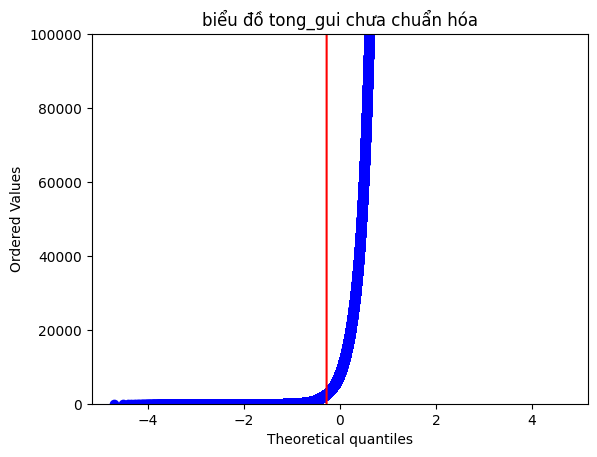

In [14]:
from scipy import stats
col="tong_gui"
stats.probplot(feat[col], dist="norm", plot=plt)
plt.ylim(feat[col].min(),100000)
plt.title(f"biểu đồ {col} chưa chuẩn hóa")
plt.show()

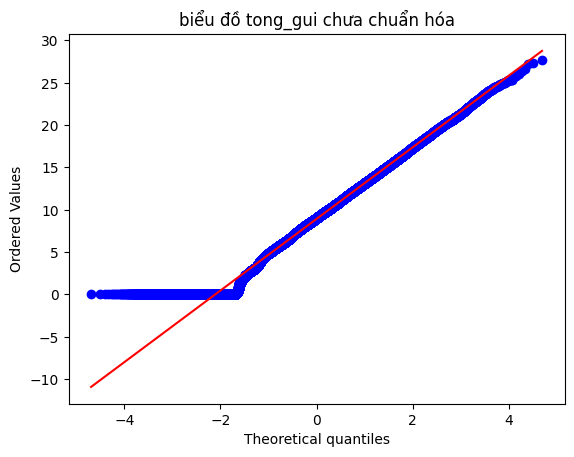

In [ ]:
from scipy import stats
col="tong_gui"
stats.probplot(np.log1p(feat[col]), dist="norm", plot=plt)
plt.title(f"biểu đồ {col} đã áp dụng log1p")
plt.show()

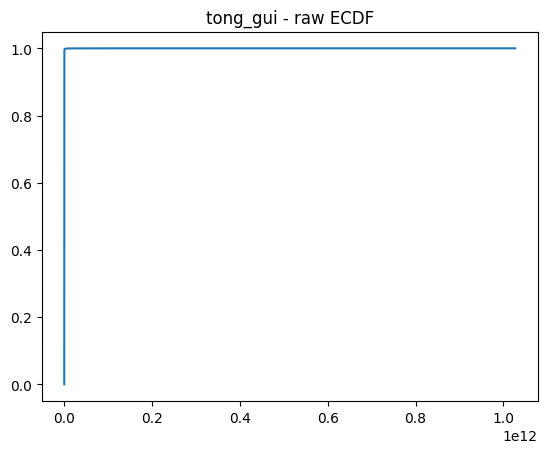

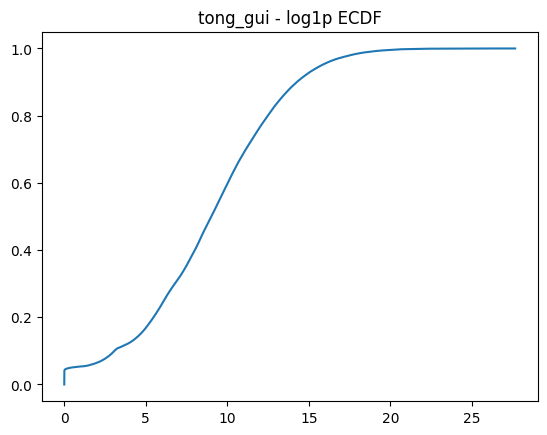

In [15]:
col = "tong_gui"
for x, t in [(feat[col], "raw"), (np.log1p(feat[col]), "log1p")]:
    xs = np.sort(x)
    plt.plot(xs, np.arange(1, len(xs)+1)/len(xs))
    plt.title(f"{col} - {t} ECDF"); plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_28332\1915152143.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([feat[col], np.log1p(feat[col])], labels=["raw", "log1p"])


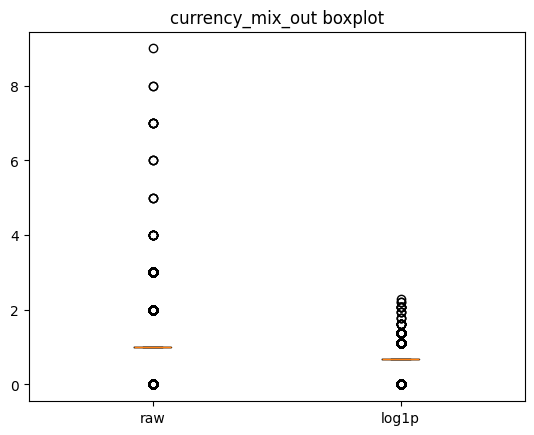

In [18]:
col = "currency_mix_out"
plt.boxplot([feat[col], np.log1p(feat[col])], labels=["raw", "log1p"])
plt.title(f"{col} boxplot"); plt.show()